In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv('ParmBotQuestionnaire.csv')
data.drop(columns="Marca temporal")
data["Caso"] = data["Caso"].replace({
    "Caso A - ParmBot interactivo": "A",
    "Caso B - ParmBot simple": "B"
})
data = data.rename(columns={
    # UES-SF Questions
    "Me sentí perdido/a en la experiencia": "FA-S.1",
    "El tiempo que pasé utilizando ParmBot se me hizo corto": "FA-S.2",
    "Me sentí absorbido/a por la experiencia" : "FA-S.3",
    "Me sentí frustrado/a al usar ParmBot" : "PU-S.1",
    "ParmBot se me hizo confuso de utilizar" : "PU-S.2",
    "Utilizar ParmBot se me hizo cansado" : "PU-S.3",
    "ParmBot me parece una aplicación atractiva" : "AE-S.1",
    "ParmBot me parece una aplicación estéticamente atractiva" : "AE-S.2",
    "ParmBot cautiva mis sentidos" : "AE-S.3",
    "Utilizar ParmBot me parece un buen uso de tiempo" : "RW-S.1",
    "Utilizar ParmBot me parece ventajoso" : "RW-S.2",
    "La experiencia me pareció interesante" : "RW-S.3",
    ###########################
    # TAM3 Questions
    "Usar ParmBot mejora mi desempeño": "PU1",
    "Usar ParmBot aumenta mi productividad": "PU2",
    "Usar ParmBot mejora mi efectividad": "PU3",
    "Usar ParmBot es útil": "PU4",
    "Interactuar con ParmBot no requiere mucho esfuerzo mental": "PEOU2",
    "ParmBot es fácil de usar": "PEOU3",
    "Es fácil hacer que ParmBot haga lo que quiero": "PEOU4",
    "Usar ParmBot es divertido": "ENJ1",
    "El proceso de usar ParmBot es agradable": "ENJ2",
    "La calidad de los resultados al usar ParmBot es alta": "OUT1",
    "No tengo problemas con la calidad de los resultados de ParmBot": "OUT2",
    "Considero que los resultados de ParmBot son excelentes": "OUT3",
    "En mi vida diaria, el uso de ParmBot podría volverse importante ": "REL1",
    "Si tuviera acceso fácil a ParmBot, lo usaría ": "BI1",
})

UESQuestions = [
    "Caso",
    "FA-S.1", "FA-S.2", "FA-S.3", "PU-S.1",
    "PU-S.2", "PU-S.3", "AE-S.1", "AE-S.2",
    "AE-S.3", "RW-S.1", "RW-S.2", "RW-S.3"
]
TAMQuestions = [
    "Caso",
    "PU1", "PU2", "PU3", "PU4", "PEOU2", "PEOU3",
    "PEOU4", "ENJ1", "ENJ2", "OUT1", "OUT2", 
    "OUT3", "REL1", "BI1"
]


data_UES = data[UESQuestions].copy()
data_TAM = data[TAMQuestions].copy()

In [9]:
CategoriesUES = ["FA", "PU", "AE", "RW"]

for cat in CategoriesUES:
    cat_cols = [col for col in UESQuestions if col.startswith(cat + "-")]
    data_UES[cat] = sum(
        (7 - data_UES[col] if col in ["PU-S.1", "PU-S.2", "PU-S.3"] else data_UES[col])
        for col in cat_cols
    ) / len(cat_cols)

data_UES["Result"] = data_UES[categories].mean(axis=1)
data_UES.head()

,Caso,FA-S.1,FA-S.2,FA-S.3,PU-S.1,PU-S.2,PU-S.3,AE-S.1,AE-S.2,AE-S.3,RW-S.1,RW-S.2,RW-S.3,FA,PU,AE,RW,Result
0,A,2,1,4,1,2,1,3,1,3,3,3,5,2.333333,5.666667,2.333333,3.666667,3.500000
1,B,1,3,4,1,1,1,5,2,3,5,5,5,2.666667,6.000000,3.333333,5.000000,4.250000
2,A,1,4,4,1,1,1,4,3,3,5,5,4,3.000000,6.000000,3.333333,4.666667,4.250000
3,B,1,1,4,1,1,2,5,2,3,4,4,5,2.000000,5.666667,3.333333,4.333333,3.833333
4,A,4,2,4,1,1,3,3,4,4,4,5,5,3.333333,5.333333,3.666667,4.666667,4.250000


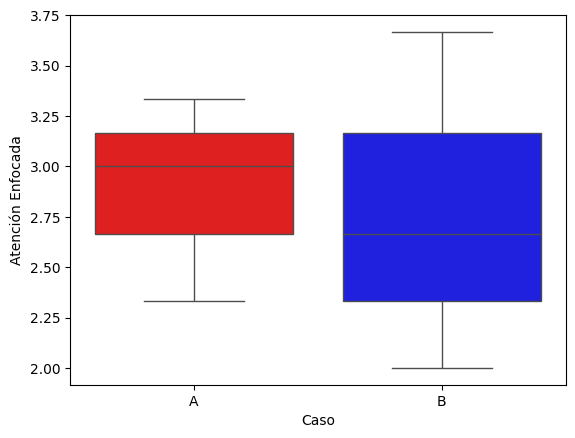

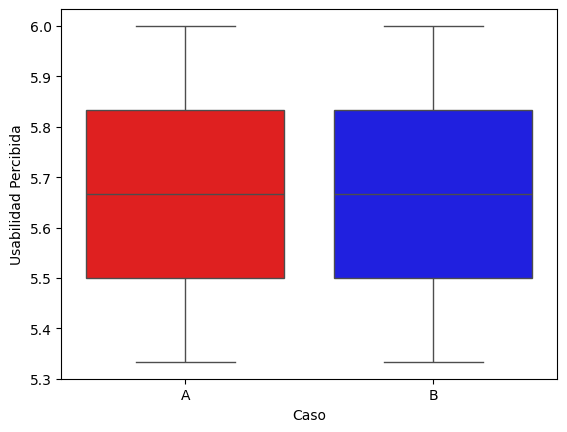

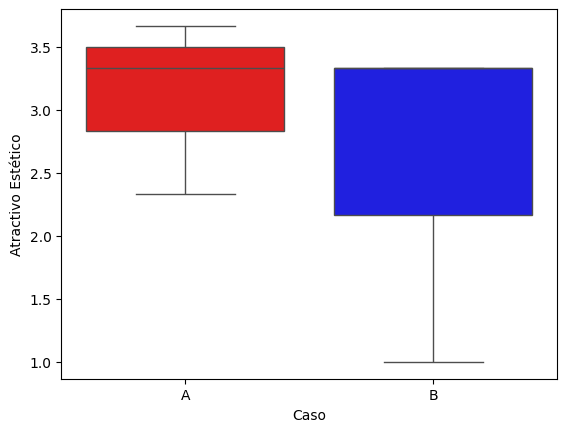

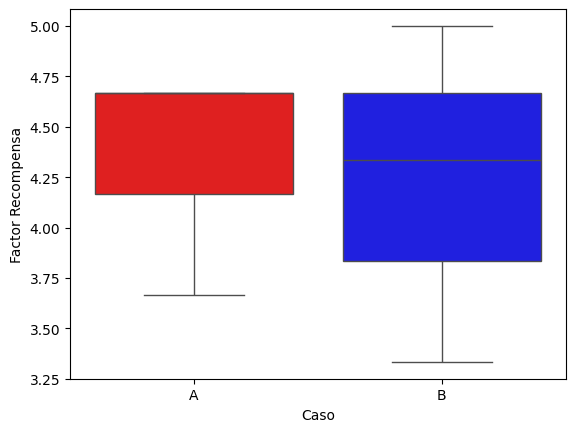

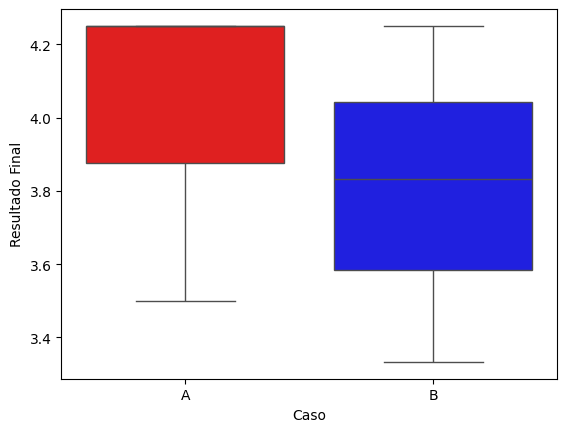

In [13]:
UESLabels = {
    "FA": "Atención Enfocada (FA)",
    "PU": "Usabilidad Percibida UES-SF (PU)",
    "AE": "Atractivo Estético (AE)",
    "RW": "Factor Recompensa (RW)",
}
colors = ["red", "blue"]

for i in CategoriesUES:
    sns.boxplot(data=data_UES, x='Caso', y=i, hue='Caso', palette=colors, legend=False)
    plt.ylabel(UESLabels[i])
    plt.show()

sns.boxplot(data=data_UES, x='Caso', y="Result", hue='Caso', palette=colors, legend=False)
plt.ylabel("Resultado UES-SF")
plt.show()

In [18]:
CategoriesTAM = ["PU", "PEOU", "ENJ", "OUT", "REL", "BI"]
data_TAM["Result"] = 0
for cat in CategoriesTAM:
    cat_cols = [col for col in TAMQuestions if col.startswith(cat)]
    data_TAM[cat] = data_TAM[cat_cols].sum(axis=1)
    data_TAM["Result"] += data_TAM[cat]
    data_TAM[cat] = data_TAM[cat] / len(cat_cols)
data_TAM["Result"] = data_TAM["Result"] / 14
data_TAM.head()

,Caso,PU1,PU2,PU3,PU4,PEOU2,PEOU3,PEOU4,ENJ1,ENJ2,...,OUT3,REL1,BI1,Result,PU,PEOU,ENJ,OUT,REL,BI
0,A,5,4,5,7,5,6,7,5,5,...,4,6,7,5.428571,5.25,6.000000,5.0,4.666667,6.0,7.0
1,B,7,5,6,7,6,7,4,1,7,...,5,7,7,5.928571,6.25,5.666667,4.0,6.333333,7.0,7.0
2,A,6,5,6,7,5,7,4,5,6,...,6,5,7,5.785714,6.00,5.333333,5.5,6.000000,5.0,7.0
3,B,6,4,5,5,7,7,5,3,2,...,4,4,3,4.642857,5.00,6.333333,2.5,4.666667,4.0,3.0
4,A,6,7,6,7,2,7,7,5,7,...,6,5,5,6.000000,6.50,5.333333,6.0,6.666667,5.0,5.0


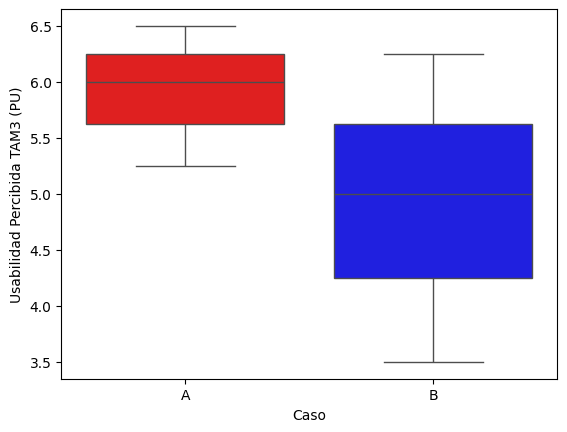

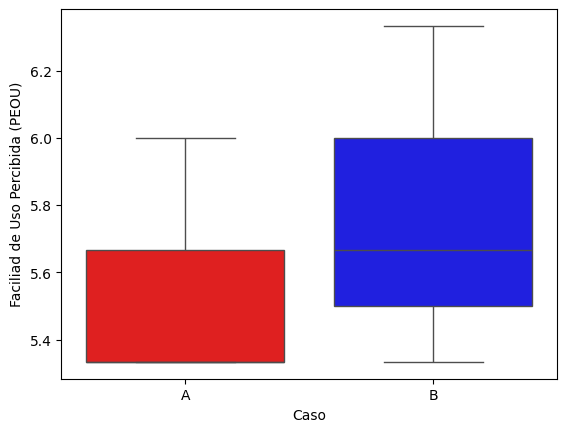

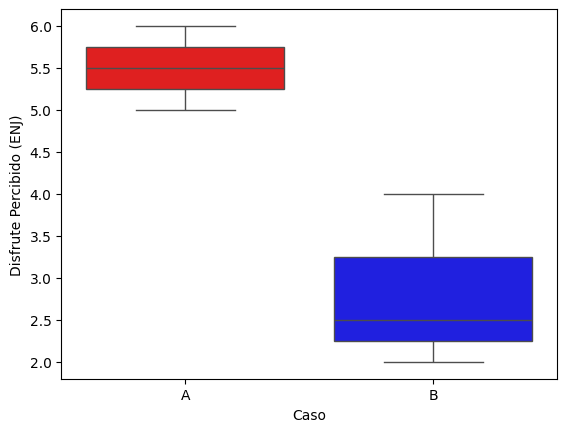

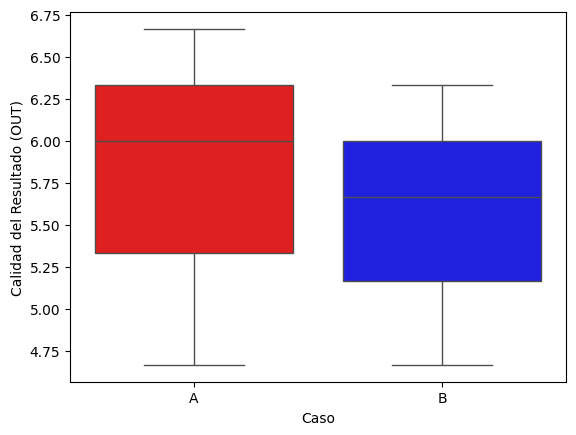

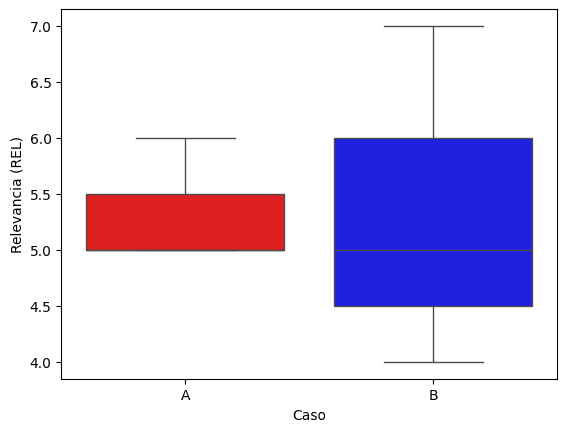

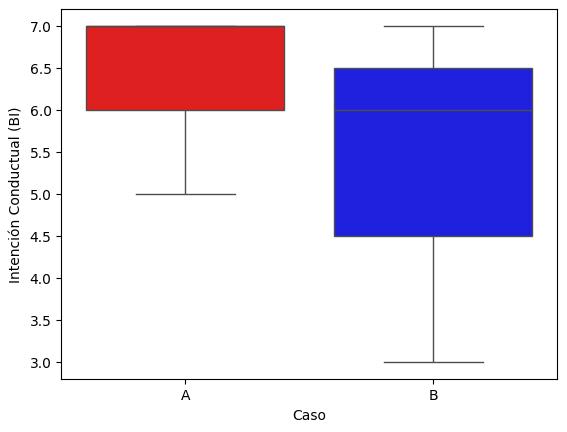

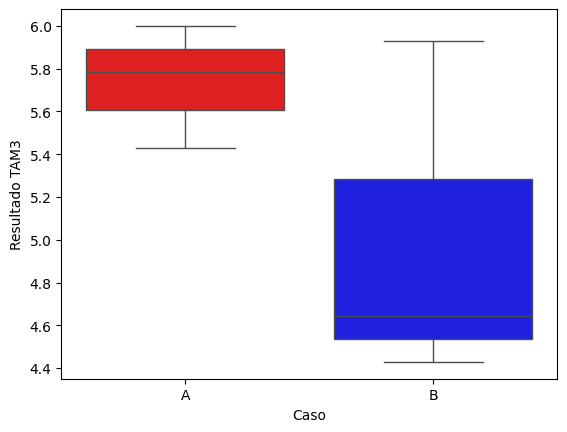

In [20]:
TAMLabels = {
    "PU": "Usabilidad Percibida TAM3 (PU)",
    "PEOU": "Faciliad de Uso Percibida (PEOU)",
    "ENJ": "Disfrute Percibido (ENJ)",
    "OUT": "Calidad del Resultado (OUT)",
    "REL": "Relevancia (REL)",
    "BI": "Intención Conductual (BI)",
}
for i in CategoriesTAM:
    sns.boxplot(data=data_TAM, x='Caso', y=i, hue='Caso', palette=colors, legend=False)
    plt.ylabel(TAMLabels[i])
    plt.show()
sns.boxplot(data=data_TAM, x='Caso', y="Result", hue='Caso', palette=colors, legend=False)
plt.ylabel("Resultado TAM3")
plt.show()

In [26]:
for i in CategoriesUES:
    print(f"{i}:")
    print(data_UES.groupby("Caso")[i].mean())
    print()
print("Resultado UES-SF:")
print(data_UES.groupby("Caso")["Result"].mean())

FA:
Caso
A    2.888889
B    2.777778
Name: FA, dtype: float64

PU:
Caso
A    5.666667
B    5.666667
Name: PU, dtype: float64

AE:
Caso
A    3.111111
B    2.555556
Name: AE, dtype: float64

RW:
Caso
A    4.333333
B    4.222222
Name: RW, dtype: float64

Resultado UES-SF:
Caso
A    4.000000
B    3.805556
Name: Result, dtype: float64


In [27]:
for i in CategoriesTAM:
    print(f"{i}:")
    print(data_TAM.groupby("Caso")[i].mean())
    print()
print("Resultado TAM3:")
print(data_TAM.groupby("Caso")["Result"].mean())

PU:
Caso
A    5.916667
B    4.916667
Name: PU, dtype: float64

PEOU:
Caso
A    5.555556
B    5.777778
Name: PEOU, dtype: float64

ENJ:
Caso
A    5.500000
B    2.833333
Name: ENJ, dtype: float64

OUT:
Caso
A    5.777778
B    5.555556
Name: OUT, dtype: float64

REL:
Caso
A    5.333333
B    5.333333
Name: REL, dtype: float64

BI:
Caso
A    6.333333
B    5.333333
Name: BI, dtype: float64

Resultado TAM3:
Caso
A    5.738095
B    5.000000
Name: Result, dtype: float64
